In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

In [2]:
from sys import path
path.append('../signals/')
path.append('../fourier/')
import signals as sg
import frequency_estimate as fe

In [3]:
d = xr.open_dataset('/Users/lampochka/Downloads/20240823a_vehicle_vessel8_REG_INTERP_TimeSeries.nc').tlsc_xymean

In [4]:
x = d.sel(t=slice(0,325))
# x = d.sel(t=slice(800,1100))

In [90]:
freq_true = 0.031
t, x = sg.cosine(350, freq_true, 2)
x = x + np.random.randn(x.size)*3.5

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import ipywidgets as widgets
from IPython.display import display

# If x is an xarray object, this will still work with x.data and x.plot(...)
# Assumes x already exists

trim_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=100,
    step=1,
    description='Trim k:',
    continuous_update=False
)

out = widgets.Output()

def update_periodogram(k):
    with out:
        out.clear_output(wait=True)

        y = x[:-k]
        freqs, pxx = periodogram(y, fs=2)
        
        fmax = freqs[pxx.argmax()]

        fig, (ax, ax1) = plt.subplots(2, 1, figsize=(12, 6))

        # Plot original trimmed signal
        try:
            x[:-k].plot(color='k', ax=ax)
        except Exception:
            ax.plot(y, color='k')
            ax.set_title(f"Signal trimmed by k={k}")

        ax.set_title(f"Signal (trimmed by {k} samples)")

        # Plot periodogram
        ax1.step(freqs, pxx, where='mid')
        
        # for i in range(1,5):
        ax1.axvline(fmax, color='r', alpha=0.2)
            
        ax1.axvline(freq_true, color='k', alpha=0.5, ls='--')
        ax1.set_xlim(0, 0.1)
        ax1.set_xlabel("Frequency")
        ax1.set_ylabel("Power spectral density")
        
        delta_freqs = freq_true - fmax
        ax1.set_title(f"Periodogram. Freq error = {delta_freqs} Hz")

        # ax1.set_ylim(0, 0.01)
        plt.tight_layout()
        plt.show()
        
        

def on_slider_change(change):
    update_periodogram(change['new'])

trim_slider.observe(on_slider_change, names='value')

display(trim_slider, out)

# Initial plot
update_periodogram(trim_slider.value)

IntSlider(value=1, continuous_update=False, description='Trim k:', min=1)

Output()

In [35]:
%load_ext autoreload
%autoreload 2

In [98]:
res = fe.max_peak_periodogram(x, 2, int(1/freq_true))

In [99]:
res['num_trimmed']

53

In [58]:
freq_true - res['peak_freq']

-0.0003971742543171161

In [59]:
res['significant']

True

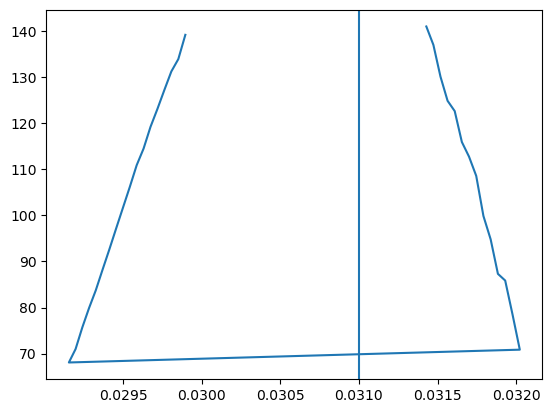

In [100]:
fs, vs = fe.scan_periodogram(x, 2, int(1/freq_true))
plt.plot(fs, vs)
plt.axvline(freq_true)